## Analisis y procesamiento de señales

# Trabajo Practico N^4

### Bernardita Aragon

En este trabajo se analizará la estimación de la amplitud y la frecuencia de una señal senoidal afectada por ruido gaussiano. Para esto se generarán 200 realizaciones de la señal y se estudiará el comportamiento de los estimadores para dos relaciones señal-ruido: 10 dB y 3 dB.

Además, se comparará el efecto de distintas ventanas sobre la estimación: rectangular, Flat-top, Blackman-Harris y Hann. Para cada caso se analizarán los resultados obtenidos mediante los espectros, histogramas y el cálculo del sesgo y la varianza de los estimadores.

Para ello generamos la siguiente señal:
$ x(n)= a0  sen (om1  n) + n_a (n) $

siendo:

$a0=\sqrt(2) $

$om1= om0 + fr (2\pi/N)$

$om0 = \pi/2$

siendo la variable aleatoria definida por la siguiente distribución de probabilidad

$fr~ U (-2,2)$

$n_a~ N(0,\sigma^2)$

Vamos a trabajar con una una potencia de señal de 1 W. Para una señal senoidal, la potencia se relaciona con la amplitud mediante:

$Ps= (a0^2)/2$

La relación señal-ruido se define como:

$SNR=10log_{10}\left(Ps/Pr\right)$

De esta expresión se despeja la potencia del ruido:

$Pr= Ps/ (10^{SNR/10})$

Como el ruido es gaussiano de media nula, su desvío estándar se obtiene como:

$sigma= \sqrt(Pr) $

Se simularan $R=200$ realizaciones de la señal. Cada señal se pasara por distintas ventanas, todas de $N=1000$ muestras a una frecuencia de muestreo de $fs=1000 Hz$. De este modo llenaremos una matriz de $N*R$. En primer lugar se analiza el caso correspondiente a una relación señal-ruido de $SNR=10dB$.

In [3]:
#importacion de modulos
import numpy as np
import matplotlib.pyplot as plt 
from scipy.signal import windows


#definiciones
a0 = np.sqrt(2) 
N = 1000
fs=1000 #hz
Ps= 1 #potencia de la senal
R=200
fr = np.random.uniform(-2,2,R)

nn=  np.arange(N)
nn= np.reshape(nn, (N,1))

om0 = (np.pi / 2) * np.ones((1,R))
om1 = om0 + fr * 2 * np.pi / N
xx = om1 * nn

#definiciones de ruido
SNR= 10 #dB
Pr = Ps / (10**(SNR/10))
sigma = np.sqrt(Pr) 
n_a= np.random.normal(0, sigma, (N,R))

#senal
yy= a0*np.sin(xx) + n_a

#vector de frecuencias
ff_vec = np.fft.fftfreq(N, 1/fs)
ff_vec = ff_vec[:N//2]

#calculo la FFT
YY = np.fft.fft(yy, axis=0)
YY_mod = np.abs(YY[:N//2, :]) / (N/2)
PYY_mod = (YY_mod**2) / 2
PYY_mod_db = 10 * np.log10(PYY_mod + 1e-12)

Para cada una de las $R=200$ realizaciones se estimarán dos parámetros de la señal: su amplitud y su frecuencia.

La amplitud se estimará tomando el módulo del espectro en la frecuencia central ${\Omega}_0$:

$\hat{a}_1^{\,i}=|X_w^{\,i}(\Omega_0)|$

mientras que la frecuencia se estimará buscando la posición en la que el módulo del espectro alcanza su valor máximo:

$\hat{\Omega}_1^{\,i}=\arg\max_{\Omega}|X_w^{\,i}(\Omega)|$

In [5]:
#estimador de amplitud
a1 = YY_mod[N//4, :]

#estimador de frecuencia
indice_max = np.argmax(YY_mod, axis=0)
#para los valores del vector indice_max pasarlo a frecuencias en hz
f1 = ff_vec[indice_max]

Para evaluar el comportamiento de los estimadores se calculan el sesgo y la varianza.
El sesgo permite medir cuánto se aleja, en promedio, el valor estimado del valor real, mientras que la varianza indica cuánto se dispersan las estimaciones entre las distintas realizaciones.

Para evaluar el comportamiento del estimador de amplitud se calculan experimentalmente su sesgo y su varianza. El valor esperado del estimador se aproxima mediante la media muestral:

$E\{\hat{a}_0\}\approx\hat{\mu}_a=\frac{1}{R}\sum_{j=0}^{R-1}\hat{a}_j$

El sesgo se calcula como:

$s_a=\hat{\mu}_a-a_0$

y la varianza como:

$v_a=\frac{1}{R}\sum_{j=0}^{R-1}(\hat{a}_j-\hat{\mu}_a)^2$

Para el estimador de amplitud, el valor real de referencia es $ao$. En el caso de la frecuencia, se compara cada estimación con la frecuencia real correspondiente a cada realización, ya que esta varía debido al término aleatorio $fr$.

In [6]:
media_a1=np.mean(a1)
sesgo_a1 = media_a1 - a0
varianza_a1 = np.mean((a1-media_a1)**2)

f0 = fs/4
f1_real = om1 * fs / (2*np.pi)

media_f1 = np.mean(f1)
sesgo_f1 = np.mean(f1 - f1_real)
varianza_f1 = np.mean((f1 - media_f1)**2)

A continuación se analiza el efecto del ventaneo sobre los estimadores. Se utiliza como referencia la ventana rectangular, correspondiente al caso sin ventaneo, y se comparan sus resultados con las ventanas Flat-top, Blackman-Harris y Hann.

Para cada ventana se vuelve a calcular el espectro y, a partir de este, los estimadores de amplitud y frecuencia junto con su sesgo y varianza.

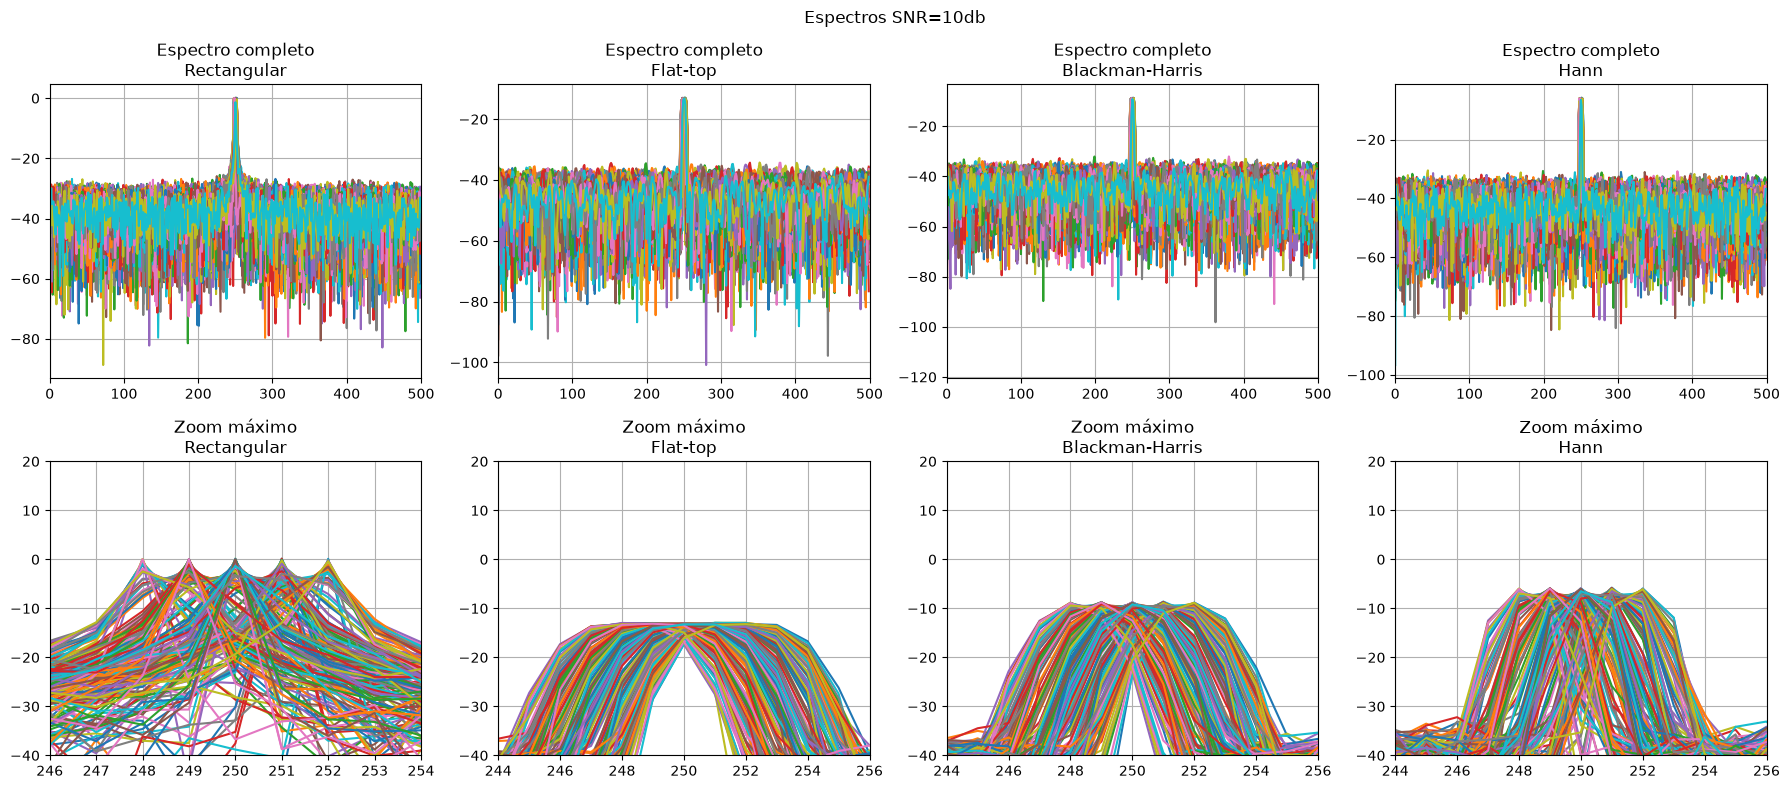

In [8]:
#flattop
w_flat = windows.flattop(N)
w_flat = np.reshape(w_flat, (N,1))
yy_flat = yy * w_flat
YY_flat = np.fft.fft(yy_flat, axis=0)
YY_flat_mod = np.abs(YY_flat[:N//2, :]) / (N/2)
PYY_flat_mod = (YY_flat_mod**2) / 2
PYY_flat_mod_db = 10 * np.log10(PYY_flat_mod + 1e-12)
a1_flat = YY_flat_mod[N//4, :]
indice_max_flat = np.argmax(YY_flat_mod, axis=0)
f1_flat = ff_vec[indice_max_flat]
media_a1_flat=np.mean(a1_flat)
sesgo_a1_flat = media_a1_flat - a0
varianza_a1_flat = np.mean((a1_flat - media_a1_flat)**2)
media_f1_flat = np.mean(f1_flat)
sesgo_f1_flat = np.mean(f1_flat - f1_real)
varianza_f1_flat = np.mean((f1_flat - media_f1_flat)**2)


#blackman-harris
w_black = windows.blackmanharris(N)
w_black = np.reshape(w_black, (N,1))
yy_black = yy * w_black
YY_black = np.fft.fft(yy_black, axis=0)
YY_black_mod = np.abs(YY_black[:N//2, :]) / (N/2)
PYY_black_mod = (YY_black_mod**2) / 2
PYY_black_mod_db = 10 * np.log10(PYY_black_mod + 1e-12)
a1_black = YY_black_mod[N//4, :]
indice_max_black = np.argmax(YY_black_mod, axis=0)
f1_black = ff_vec[indice_max_black]
media_a1_black=np.mean(a1_black)
sesgo_a1_black = media_a1_black - a0
varianza_a1_black = np.mean((a1_black - media_a1_black)**2)
media_f1_black = np.mean(f1_black)
sesgo_f1_black = np.mean(f1_black - f1_real)
varianza_f1_black = np.mean((f1_black - media_f1_black)**2)

#hann
w_hann = windows.hann(N)
w_hann = np.reshape(w_hann, (N,1))
yy_hann = yy * w_hann
YY_hann = np.fft.fft(yy_hann, axis=0)
YY_hann_mod = np.abs(YY_hann[:N//2, :]) / (N/2)
PYY_hann_mod = (YY_hann_mod**2) / 2
PYY_hann_mod_db = 10 * np.log10(PYY_hann_mod + 1e-12)
a1_hann = YY_hann_mod[N//4, :]
indice_max_hann = np.argmax(YY_hann_mod, axis=0)
f1_hann = ff_vec[indice_max_hann]
media_a1_hann=np.mean(a1_hann)
sesgo_a1_hann = media_a1_hann - a0
varianza_a1_hann = np.mean((a1_hann - media_a1_hann)**2)
media_f1_hann = np.mean(f1_hann)
sesgo_f1_hann = np.mean(f1_hann - f1_real)
varianza_f1_hann = np.mean((f1_hann - media_f1_hann)**2)


#GRAFICOS ESPECTROS CON LAS 4 VENTANAS
plt.figure(figsize=(18,8))
plt.suptitle('Espectros SNR=10db')
# Rectangular
plt.subplot(2,4,1)
plt.plot(ff_vec, PYY_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nRectangular')
plt.grid()
# Flat-top
plt.subplot(2,4,2)
plt.plot(ff_vec, PYY_flat_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nFlat-top')
plt.grid()
# Blackman-Harris
plt.subplot(2,4,3)
plt.plot(ff_vec, PYY_black_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nBlackman-Harris')
plt.grid()
# Hann
plt.subplot(2,4,4)
plt.plot(ff_vec, PYY_hann_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nHann')
plt.grid()
#con zoom
# Rectangular - zoom
plt.subplot(2,4,5)
plt.plot(ff_vec, PYY_mod_db)
plt.xlim(246,254)
plt.ylim(-40,20)
plt.title('Zoom máximo\nRectangular')
plt.grid()
# Flat-top - zoom
plt.subplot(2,4,6)
plt.plot(ff_vec, PYY_flat_mod_db)
plt.xlim(244,256)
plt.ylim(-40,20)
plt.title('Zoom máximo\nFlat-top')
plt.grid()
# Blackman-Harris - zoom
plt.subplot(2,4,7)
plt.plot(ff_vec, PYY_black_mod_db)
plt.xlim(244,256)
plt.ylim(-40,20)
plt.title('Zoom máximo\nBlackman-Harris')
plt.grid()
# Hann - zoom
plt.subplot(2,4,8)
plt.plot(ff_vec, PYY_hann_mod_db)
plt.xlim(244,256)
plt.ylim(-40,20)
plt.title('Zoom máximo\nHann')
plt.grid()

plt.tight_layout()
plt.show()

Al comparar los espectros se observan diferencias en la forma del lóbulo principal para cada ventana. 

La ventana rectangular presenta el lóbulo principal más angosto, por lo que permite localizar con mayor precisión la frecuencia, aunque presenta mayor dispersión espectral alrededor del máximo.

La ventana Flat-top presenta un lóbulo principal considerablemente más ancho y con una zona superior más plana. Esta característica hace que el valor del espectro varíe menos cuando la frecuencia de la señal se desplaza respecto del bin central.

La ventana Blackman-Harris también ensancha el lóbulo principal, pero reduce considerablemente los lóbulos laterales. 

Por su parte, la ventana Hann presenta un comportamiento intermedio entre la ventana rectangular y las ventanas de mayor atenuación lateral.

En general, se puede ver que al elegir una ventana hay que buscar un equilibrio entre poder distinguir bien la frecuencia y reducir el desparramo espectral.

A continuación, se representan mediante histogramas los valores obtenidos para los estimadores de amplitud y frecuencia en las $R=200$ realizaciones.

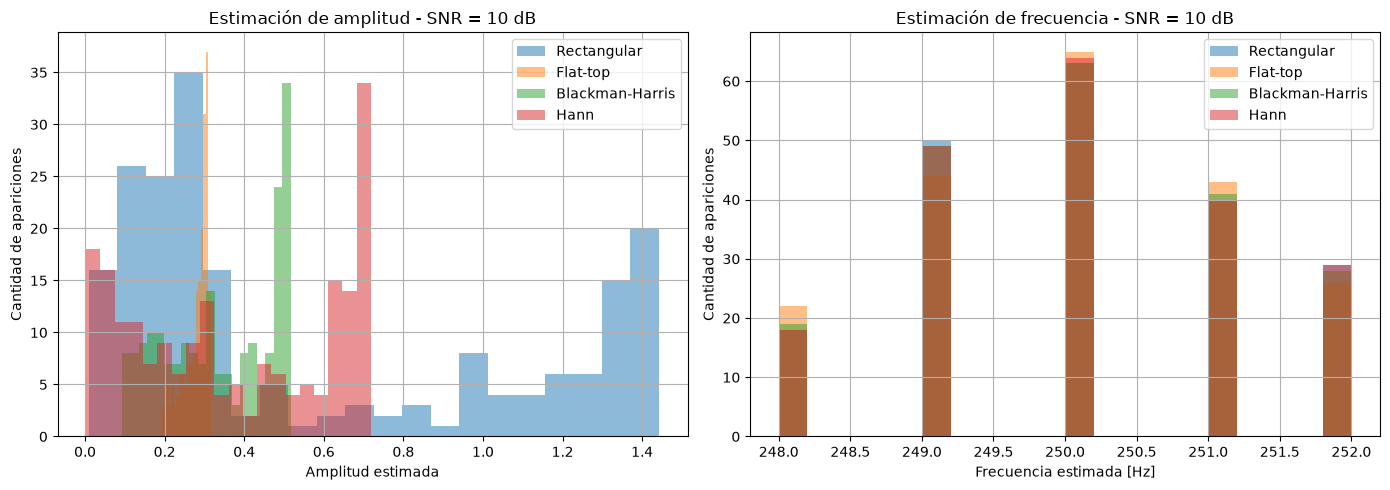

In [9]:
#HISTOGRAMAS
plt.figure(figsize=(14,5))
# HISTOGRAMA DE AMPLITUD
plt.subplot(1,2,1)
plt.hist(a1, bins=20, alpha=0.5, label='Rectangular')
plt.hist(a1_flat, bins=20, alpha=0.5, label='Flat-top')
plt.hist(a1_black, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(a1_hann, bins=20, alpha=0.5, label='Hann')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de amplitud - SNR = 10 dB')
plt.legend()
plt.grid()

# HISTOGRAMA DE FRECUENCIA
plt.subplot(1,2,2)
plt.hist(f1, bins=20, alpha=0.5, label='Rectangular')
plt.hist(f1_flat, bins=20, alpha=0.5, label='Flat-top')
plt.hist(f1_black, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(f1_hann, bins=20, alpha=0.5, label='Hann')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de frecuencia - SNR = 10 dB')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

En el histograma de amplitud se observa que la ventana rectangular presenta la mayor dispersión de los valores estimados. En cambio, la ventana Flat-top concentra mucho más las estimaciones, mientras que Blackman-Harris y Hann presentan comportamientos intermedios. También se observa que las distintas ventanas producen estimaciones de amplitud en diferentes rangos, debido al efecto que cada ventana tiene sobre el espectro.

En la estimación de frecuencia, las cuatro ventanas presentan un comportamiento muy parecido. Los histogramas se encuentran prácticamente superpuestos y la mayor cantidad de estimaciones se concentra alrededor de $250 Hz$, que corresponde a la frecuencia central. Además, los valores aparecen separados de a $1 Hz$ debido a la resolución en frecuencia de la FFT.

Finalmente, se resumen los resultados obtenidos para cada ventana mediante el sesgo y la varianza de los estimadores de amplitud y frecuencia.

In [13]:
# TABLA DE RESULTADOS - SNR = 10 dB

print("\nESTIMACIÓN DE AMPLITUD - SNR = 10 dB")
print("-" * 50)
print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 50)
print(f"{'Rectangular':<20} {sesgo_a1:>12.4f} {varianza_a1:>12.4f}")
print(f"{'Flat-top':<20} {sesgo_a1_flat:>12.4f} {varianza_a1_flat:>12.4f}")
print(f"{'Blackman-Harris':<20} {sesgo_a1_black:>12.4f} {varianza_a1_black:>12.4f}")
print(f"{'Hann':<20} {sesgo_a1_hann:>12.4f} {varianza_a1_hann:>12.4f}")
print("-" * 50)

print("\nESTIMACIÓN DE FRECUENCIA - SNR = 10 dB")
print("-" * 50)
print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>15}")
print("-" * 50)
print(f"{'Rectangular':<20} {sesgo_f1:>12.4f} {varianza_f1:>15.4f}")
print(f"{'Flat-top':<20} {sesgo_f1_flat:>12.4f} {varianza_f1_flat:>15.4f}")
print(f"{'Blackman-Harris':<20} {sesgo_f1_black:>12.4f} {varianza_f1_black:>15.4f}")
print(f"{'Hann':<20} {sesgo_f1_hann:>12.4f} {varianza_f1_hann:>15.4f}")
print("-" * 50)


ESTIMACIÓN DE AMPLITUD - SNR = 10 dB
--------------------------------------------------
Ventana                     Sesgo     Varianza
--------------------------------------------------
Rectangular               -0.8416       0.2479
Flat-top                  -1.1347       0.0010
Blackman-Harris           -1.0759       0.0184
Hann                      -1.0422       0.0633
--------------------------------------------------

ESTIMACIÓN DE FRECUENCIA - SNR = 10 dB
--------------------------------------------------
Ventana                     Sesgo        Varianza
--------------------------------------------------
Rectangular                0.0030          1.3864
Flat-top                  -0.0220          1.3938
Blackman-Harris           -0.0070          1.3875
Hann                       0.0080          1.3808
--------------------------------------------------


Los resultados de la tabla coinciden con lo observado en los histogramas. En la estimación de amplitud, la ventana Flat-top presenta la menor varianza, por lo que sus estimaciones se encuentran más concentradas, mientras que la ventana rectangular presenta la mayor dispersión. Blackman-Harris y Hann muestran valores intermedios.

En la estimación de frecuencia, los sesgos son muy pequeños para todas las ventanas y las varianzas son muy similares, por lo que no se observan diferencias importantes entre ellas para este caso.

A continuación se repite el mismo procedimiento para una relación señal-ruido de $SNR=3 dB$, con el objetivo de analizar cómo afecta un mayor nivel de ruido a los estimadores.

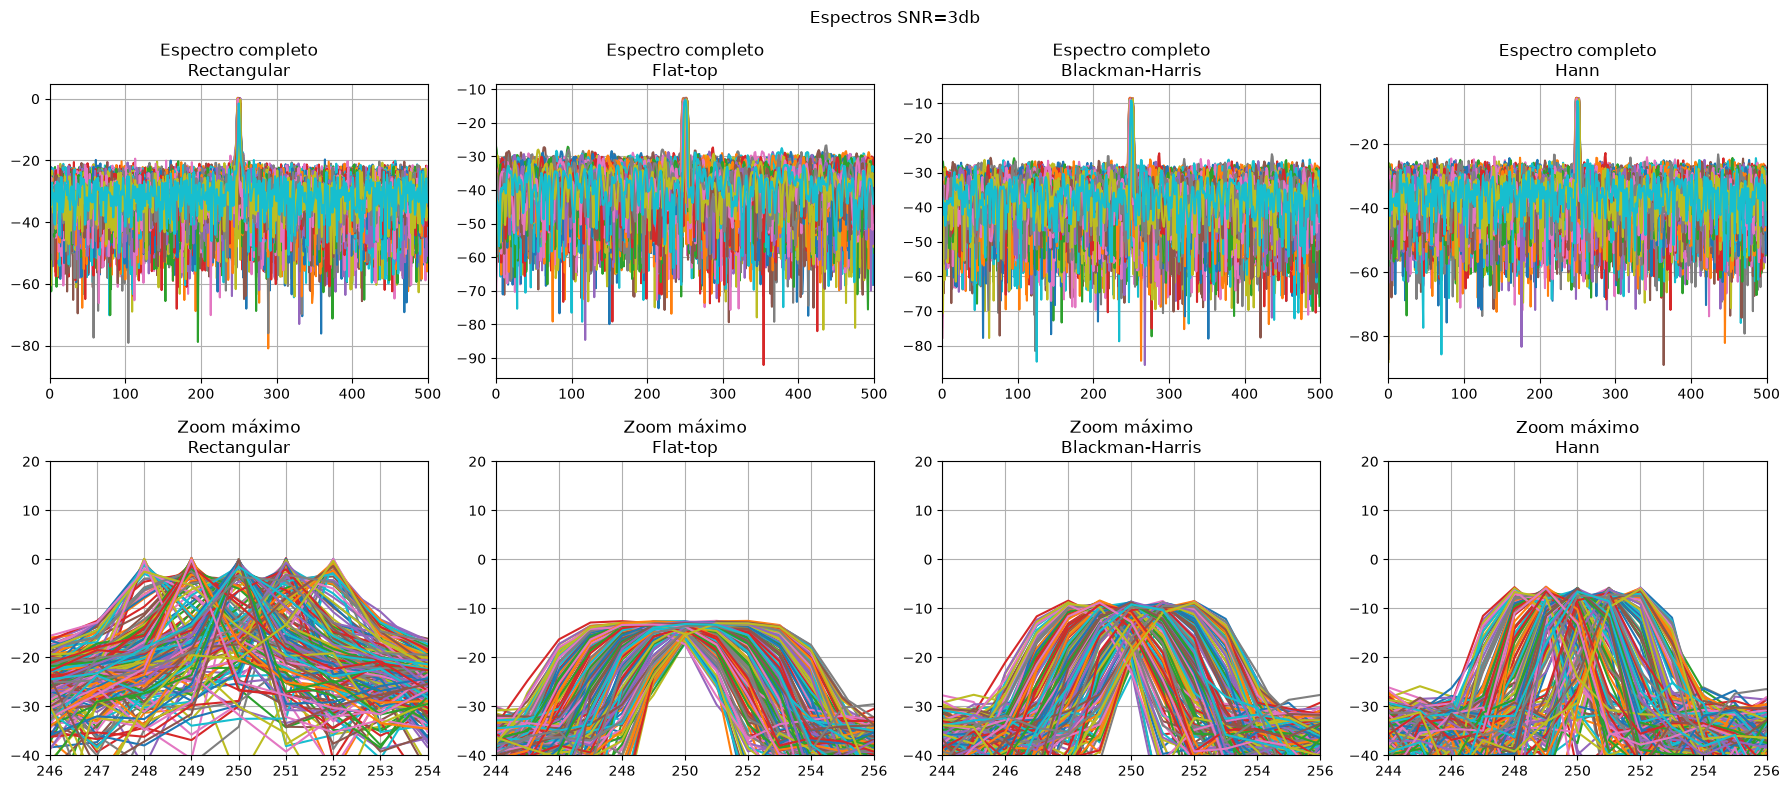

In [14]:
SNR= 3 #dB
Pr = Ps / (10**(SNR/10))
sigma = np.sqrt(Pr) 
n_a= np.random.normal(0, sigma, (N,R))

yy= a0*np.sin(xx) + n_a

#vector de frecuencias
ff_vec = np.fft.fftfreq(N, 1/fs)
ff_vec = ff_vec[:N//2]

#calculo la FFT
YY = np.fft.fft(yy, axis=0)
YY_mod = np.abs(YY[:N//2, :]) / (N/2)
PYY_mod = (YY_mod**2) / 2
PYY_mod_db = 10 * np.log10(PYY_mod + 1e-12)


#estimador de amplitud
a1 = YY_mod[N//4, :]

#estimador de frecuencia
indice_max = np.argmax(YY_mod, axis=0)
#para los valores del vector indice_max pasarlo a frecuencias en hz
f1 = ff_vec[indice_max]


media_a1=np.mean(a1)
sesgo_a1 = media_a1 - a0
varianza_a1 = np.mean((a1-media_a1)**2)

f0 = fs/4
f1_real = om1 * fs / (2*np.pi)

media_f1 = np.mean(f1)
sesgo_f1 = np.mean(f1 - f1_real)
varianza_f1 = np.mean((f1 - media_f1)**2)

#VENTANAS

#flattop
w_flat = windows.flattop(N)
w_flat = np.reshape(w_flat, (N,1))
yy_flat = yy * w_flat
YY_flat = np.fft.fft(yy_flat, axis=0)
YY_flat_mod = np.abs(YY_flat[:N//2, :]) / (N/2)
PYY_flat_mod = (YY_flat_mod**2) / 2
PYY_flat_mod_db = 10 * np.log10(PYY_flat_mod + 1e-12)
a1_flat = YY_flat_mod[N//4, :]
indice_max_flat = np.argmax(YY_flat_mod, axis=0)
f1_flat = ff_vec[indice_max_flat]
media_a1_flat=np.mean(a1_flat)
sesgo_a1_flat = media_a1_flat - a0
varianza_a1_flat = np.mean((a1_flat - media_a1_flat)**2)
media_f1_flat = np.mean(f1_flat)
sesgo_f1_flat = np.mean(f1_flat - f1_real)
varianza_f1_flat = np.mean((f1_flat - media_f1_flat)**2)


#blackman-harris
w_black = windows.blackmanharris(N)
w_black = np.reshape(w_black, (N,1))
yy_black = yy * w_black
YY_black = np.fft.fft(yy_black, axis=0)
YY_black_mod = np.abs(YY_black[:N//2, :]) / (N/2)
PYY_black_mod = (YY_black_mod**2) / 2
PYY_black_mod_db = 10 * np.log10(PYY_black_mod + 1e-12)
a1_black = YY_black_mod[N//4, :]
indice_max_black = np.argmax(YY_black_mod, axis=0)
f1_black = ff_vec[indice_max_black]
media_a1_black=np.mean(a1_black)
sesgo_a1_black = media_a1_black - a0
varianza_a1_black = np.mean((a1_black - media_a1_black)**2)
media_f1_black = np.mean(f1_black)
sesgo_f1_black = np.mean(f1_black - f1_real)
varianza_f1_black = np.mean((f1_black - media_f1_black)**2)

#hann
w_hann = windows.hann(N)
w_hann = np.reshape(w_hann, (N,1))
yy_hann = yy * w_hann
YY_hann = np.fft.fft(yy_hann, axis=0)
YY_hann_mod = np.abs(YY_hann[:N//2, :]) / (N/2)
PYY_hann_mod = (YY_hann_mod**2) / 2
PYY_hann_mod_db = 10 * np.log10(PYY_hann_mod + 1e-12)
a1_hann = YY_hann_mod[N//4, :]
indice_max_hann = np.argmax(YY_hann_mod, axis=0)
f1_hann = ff_vec[indice_max_hann]
media_a1_hann=np.mean(a1_hann)
sesgo_a1_hann = media_a1_hann - a0
varianza_a1_hann = np.mean((a1_hann - media_a1_hann)**2)
media_f1_hann = np.mean(f1_hann)
sesgo_f1_hann = np.mean(f1_hann - f1_real)
varianza_f1_hann = np.mean((f1_hann - media_f1_hann)**2)


#GRAFICOS ESPECTROS CON LAS 4 VENTANAS
plt.figure(figsize=(18,8))
plt.suptitle('Espectros SNR=3db')
# Rectangular
plt.subplot(2,4,1)
plt.plot(ff_vec, PYY_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nRectangular')
plt.grid()
# Flat-top
plt.subplot(2,4,2)
plt.plot(ff_vec, PYY_flat_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nFlat-top')
plt.grid()
# Blackman-Harris
plt.subplot(2,4,3)
plt.plot(ff_vec, PYY_black_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nBlackman-Harris')
plt.grid()
# Hann
plt.subplot(2,4,4)
plt.plot(ff_vec, PYY_hann_mod_db)
plt.xlim(0, fs/2)
plt.title('Espectro completo\nHann')
plt.grid()
#con zoom
# Rectangular - zoom
plt.subplot(2,4,5)
plt.plot(ff_vec, PYY_mod_db)
plt.xlim(246,254)
plt.ylim(-40,20)
plt.title('Zoom máximo\nRectangular')
plt.grid()
# Flat-top - zoom
plt.subplot(2,4,6)
plt.plot(ff_vec, PYY_flat_mod_db)
plt.xlim(244,256)
plt.ylim(-40,20)
plt.title('Zoom máximo\nFlat-top')
plt.grid()
# Blackman-Harris - zoom
plt.subplot(2,4,7)
plt.plot(ff_vec, PYY_black_mod_db)
plt.xlim(244,256)
plt.ylim(-40,20)
plt.title('Zoom máximo\nBlackman-Harris')
plt.grid()
# Hann - zoom
plt.subplot(2,4,8)
plt.plot(ff_vec, PYY_hann_mod_db)
plt.xlim(244,256)
plt.ylim(-40,20)
plt.title('Zoom máximo\nHann')
plt.grid()

plt.tight_layout()
plt.show()

Para $SNR=3 dB$ se observa un mayor nivel de ruido en los espectros respecto del caso de $10 dB$, por lo que el piso de ruido se encuentra más elevado. Aun así, las diferencias entre las ventanas se mantienen: la rectangular presenta un lóbulo principal más angosto, mientras que Flat-top, Blackman-Harris y Hann presentan lóbulos más anchos.

Por lo tanto, al disminuir el $SNR$ aumenta la influencia del ruido, aunque se siguen observando las características propias de cada ventana.

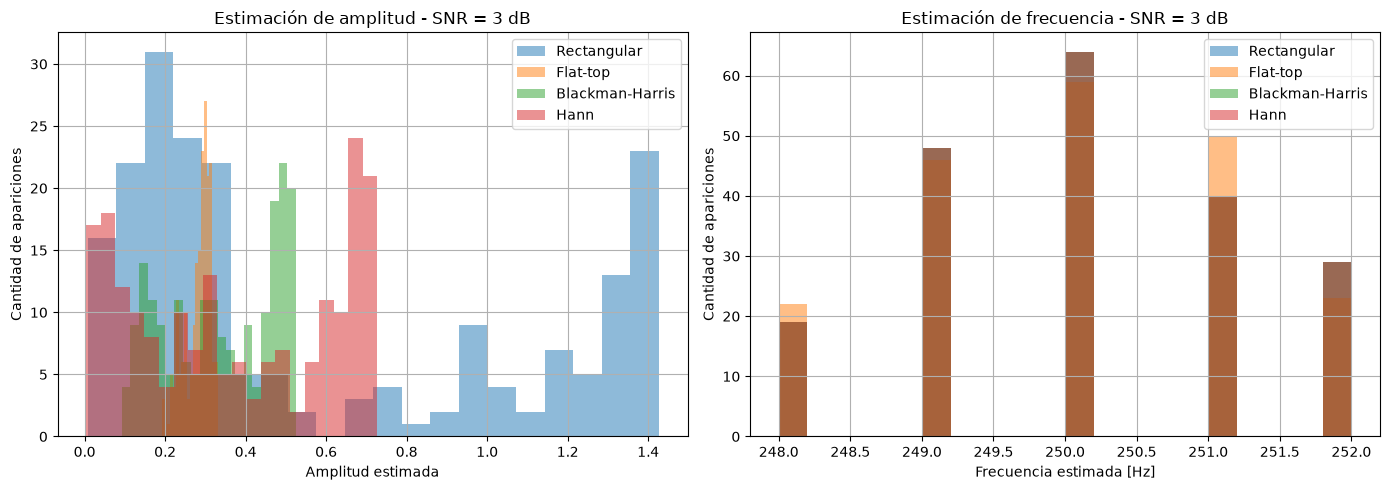

In [16]:
#HISTOGRAMAS
plt.figure(figsize=(14,5))
# HISTOGRAMA DE AMPLITUD
plt.subplot(1,2,1)
plt.hist(a1, bins=20, alpha=0.5, label='Rectangular')
plt.hist(a1_flat, bins=20, alpha=0.5, label='Flat-top')
plt.hist(a1_black, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(a1_hann, bins=20, alpha=0.5, label='Hann')
plt.xlabel('Amplitud estimada')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de amplitud - SNR = 3 dB')
plt.legend()
plt.grid()

# HISTOGRAMA DE FRECUENCIA
plt.subplot(1,2,2)
plt.hist(f1, bins=20, alpha=0.5, label='Rectangular')
plt.hist(f1_flat, bins=20, alpha=0.5, label='Flat-top')
plt.hist(f1_black, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(f1_hann, bins=20, alpha=0.5, label='Hann')
plt.xlabel('Frecuencia estimada [Hz]')
plt.ylabel('Cantidad de apariciones')
plt.title('Estimación de frecuencia - SNR = 3 dB')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

En el histograma de amplitud se observa nuevamente que la ventana rectangular presenta la mayor dispersión de las estimaciones, mientras que la ventana Flat-top concentra los valores en un rango mucho más pequeño. Las ventanas Blackman-Harris y Hann presentan comportamientos intermedios.

Para la estimación de frecuencia, las cuatro ventanas muestran resultados muy similares y los histogramas se encuentran prácticamente superpuestos. La mayor cantidad de estimaciones se concentra alrededor de los $250 Hz$ y los valores aparecen separados de a $1 Hz$, debido a la resolución en frecuencia de la FFT.

In [17]:
# TABLA DE RESULTADOS - SNR = 3 dB

print("\nESTIMACIÓN DE AMPLITUD - SNR = 3 dB")
print("-" * 50)
print(f"{'Ventana':<20} {'Sesgo':>12} {'Varianza':>12}")
print("-" * 50)
print(f"{'Rectangular':<20} {sesgo_a1:>12.4f} {varianza_a1:>12.4f}")
print(f"{'Flat-top':<20} {sesgo_a1_flat:>12.4f} {varianza_a1_flat:>12.4f}")
print(f"{'Blackman-Harris':<20} {sesgo_a1_black:>12.4f} {varianza_a1_black:>12.4f}")
print(f"{'Hann':<20} {sesgo_a1_hann:>12.4f} {varianza_a1_hann:>12.4f}")
print("-" * 50)


print("\nESTIMACIÓN DE FRECUENCIA - SNR = 3 dB")
print("-" * 50)
print(f"{'Ventana':<20} {'Sesgo [Hz]':>12} {'Varianza [Hz²]':>15}")
print("-" * 50)
print(f"{'Rectangular':<20} {sesgo_f1:>12.4f} {varianza_f1:>15.4f}")
print(f"{'Flat-top':<20} {sesgo_f1_flat:>12.4f} {varianza_f1_flat:>15.4f}")
print(f"{'Blackman-Harris':<20} {sesgo_f1_black:>12.4f} {varianza_f1_black:>15.4f}")
print(f"{'Hann':<20} {sesgo_f1_hann:>12.4f} {varianza_f1_hann:>15.4f}")
print("-" * 50)


ESTIMACIÓN DE AMPLITUD - SNR = 3 dB
--------------------------------------------------
Ventana                     Sesgo     Varianza
--------------------------------------------------
Rectangular               -0.8447       0.2420
Flat-top                  -1.1341       0.0011
Blackman-Harris           -1.0759       0.0184
Hann                      -1.0423       0.0623
--------------------------------------------------

ESTIMACIÓN DE FRECUENCIA - SNR = 3 dB
--------------------------------------------------
Ventana                Sesgo [Hz]  Varianza [Hz²]
--------------------------------------------------
Rectangular                0.0030          1.3964
Flat-top                  -0.0270          1.3791
Blackman-Harris            0.0030          1.3964
Hann                       0.0030          1.3964
--------------------------------------------------


Los valores de la tabla coinciden con lo observado en los histogramas. Para la amplitud, la ventana Flat-top presenta la menor varianza $0.0011$, seguida por Blackman-Harris y Hann, mientras que la ventana rectangular presenta la mayor $0.2420$. Esto explica la diferencia en la dispersión observada en los histogramas.

En cuanto a la frecuencia, todas las ventanas presentan sesgos cercanos a cero y varianzas muy similares, alrededor de $1.4\ \text{Hz}^2$. Por lo tanto, para este nivel de ruido no se observan diferencias importantes entre las ventanas en la estimación de frecuencia.

A lo largo de este trabajo pudimos aprender cómo aplicar distintas ventanas a una señal senoidal afectada por ruido y analizar cómo influyen sobre la estimación de su amplitud y frecuencia. Para esto comparamos los espectros obtenidos con cada ventana, sus histogramas, sesgo y varianza.

En la estimación de amplitud pudimos ver diferencias claras entre las ventanas. La ventana Flat-top fue la que presentó la menor varianza, por lo que las estimaciones quedaron mucho más concentradas, mientras que la rectangular mostró una mayor dispersión. 

Para la estimación de frecuencia, en cambio, las diferencias entre las ventanas fueron mucho menores. Los histogramas quedaron prácticamente superpuestos y tanto el sesgo como la varianza tomaron valores similares. 

Por último, al comparar los casos de $SNR=10 dB$ y $SNR=3 dB$, teniendo en cuenta el efecto del aumento del ruido, los estimadores mantuvieron un comportamiento bastante similar en ambos casos. 

También cabe destacar que este trabajo nos permitio ver que no hay una ventana “mejor”, sino que depende de qué queremos observar en la señal. Cada ventana tiene ventajas y desventajas, por lo que la elección cambia según si nos interesa estimar mejor la amplitud, la frecuencia o reducir el desparramo espectral.